In [1]:
"""
signal_analysis2 — rewritten from scratch
------------------------------------------
Single source: prompts_with_response_task4_3day.csv

This file is the final output of the full pipeline:
  task3_1_fixed  → adds behavioral_improvement, signal_change (z-score normalized)
  task4          → adds prompt_type
  Copy_of_debugging → adds response_type_v2 (authoritative LLM classification)

Unit of analysis : 1 row = 1 journal entry per domain
Improvement flag : behavioral_improvement (yes/no) — z-score composite, direction-aware
Response type    : response_type_v2 — single authoritative classification

Levels:
  1 — Overall INTENTION vs REFLECTION
  2 — Per domain INTENTION vs REFLECTION
  3 — Within improved entries only: INTENTION vs REFLECTION split + magnitude

Outputs:
  entry_level_overall.csv
  entry_level_domain.csv
  entry_level_improved_only.csv
"""

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, mannwhitneyu

# ── Load — single source ──────────────────────────────────────────────────────
df = pd.read_csv('prompts_with_response_task4_3day.csv')
print(f"Loaded: {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")

# ── Clean ─────────────────────────────────────────────────────────────────────
# Drop rows with no improvement data
before = len(df)
df = df[df['behavioral_improvement'].notna()].copy()
print(f"Dropped {before - len(df)} rows with no improvement signal")

# Keep only INTENTION and REFLECTION (drop NOT_APPLICABLE and NaN response types)
before = len(df)
df = df[df['response_type_v2'].isin(['INTENTION', 'REFLECTION'])].copy()
print(f"Dropped {before - len(df)} rows (NOT_APPLICABLE or unclassified)")

# Binary improvement flag
df['improved_bin'] = (df['behavioral_improvement'] == 'yes').astype(int)

# Rename domain column for consistency
df = df.rename(columns={'behavioral_domain_category': 'domain'})

# Exclude 'general' domain (no signal mapping)
df = df[df['domain'] != 'general'].copy()
df = df.reset_index(drop=True)

print(f"\nFinal dataset: {len(df)} rows")
print(f"  INTENTION : {(df['response_type_v2']=='INTENTION').sum()}")
print(f"  REFLECTION: {(df['response_type_v2']=='REFLECTION').sum()}")
print(f"\nBreakdown by domain:")
print(df.groupby(['domain','response_type_v2']).agg(
    n=('improved_bin','count'),
    improved=('improved_bin','sum')
).to_string())

DOMAINS = ['digital_habits', 'social_interaction', 'sleep', 'physical_fitness']


# ── Helpers ───────────────────────────────────────────────────────────────────
def odds_ratio_ci(a_yes, a_no, b_yes, b_no, z=1.96):
    """OR + 95% CI with Haldane-Anscombe correction for zero cells."""
    if min(a_yes, a_no, b_yes, b_no) == 0:
        a_yes += 0.5; a_no += 0.5; b_yes += 0.5; b_no += 0.5
    if b_yes == 0 or a_no == 0:
        return np.nan, np.nan, np.nan
    or_val = (a_yes * b_no) / (a_no * b_yes)
    log_or = np.log(or_val)
    se     = np.sqrt(1/a_yes + 1/a_no + 1/b_yes + 1/b_no)
    return round(or_val, 3), round(np.exp(log_or - z*se), 3), round(np.exp(log_or + z*se), 3)


def rank_biserial_r(u_stat, n1, n2):
    return round(1 - (2 * u_stat) / (n1 * n2), 3)


def run_tests(A, B, label):
    """
    Fisher's exact on improved_bin (binary).
    Mann-Whitney U on signal_change (continuous magnitude).
    """
    na, nb  = len(A), len(B)
    ay      = int(A['improved_bin'].sum());  an = na - ay
    by      = int(B['improved_bin'].sum());  bn = nb - by
    pct_a   = ay/na*100 if na > 0 else np.nan
    pct_b   = by/nb*100 if nb > 0 else np.nan

    _, fp              = fisher_exact([[ay, an], [by, bn]])
    or_val, ci_lo, ci_hi = odds_ratio_ci(ay, an, by, bn)

    ca = A['signal_change'].dropna()
    cb = B['signal_change'].dropna()
    if len(ca) >= 2 and len(cb) >= 2:
        u_stat, mp = mannwhitneyu(ca, cb, alternative='two-sided')
        rb_r       = rank_biserial_r(u_stat, len(ca), len(cb))
    else:
        mp, rb_r = np.nan, np.nan

    sig_f = fp < 0.05
    sig_m = (not np.isnan(mp)) and mp < 0.05

    print(f"\n{'-'*65}")
    print(f"  {label}")
    print(f"  INTENTION  (A): N={na:>4} | improved {ay}/{na} = {pct_a:.1f}%  not={an}")
    print(f"  REFLECTION (B): N={nb:>4} | improved {by}/{nb} = {pct_b:.1f}%  not={bn}")
    print(f"  signal_change  median A={ca.median():+.4f}  B={cb.median():+.4f}")
    print(f"  signal_change  mean  A={ca.mean():+.4f}  B={cb.mean():+.4f}")
    print(f"\n  Fisher's exact : p = {fp:.4f}  {'← SIGNIFICANT' if sig_f else 'n.s.'}")
    print(f"  Odds ratio     : OR = {or_val}  95% CI [{ci_lo}, {ci_hi}]")
    if not np.isnan(mp):
        print(f"  Mann-Whitney U : p = {mp:.4f}  {'← SIGNIFICANT' if sig_m else 'n.s.'}  | rank-biserial r = {rb_r}")
    else:
        print(f"  Mann-Whitney U : insufficient data")

    return {
        'label'              : label,
        'n_intention'        : na,
        'n_reflection'       : nb,
        'intention_improved' : ay,
        'intention_not'      : an,
        'reflection_improved': by,
        'reflection_not'     : bn,
        'intention_pct'      : round(pct_a, 1),
        'reflection_pct'     : round(pct_b, 1),
        'intention_med_change': round(ca.median(), 4) if not ca.empty else np.nan,
        'reflection_med_change': round(cb.median(), 4) if not cb.empty else np.nan,
        'fisher_p'           : round(fp, 4),
        'fisher_sig'         : sig_f,
        'odds_ratio'         : or_val,
        'or_ci_lo'           : ci_lo,
        'or_ci_hi'           : ci_hi,
        'mannwhitney_p'      : round(mp, 4) if not np.isnan(mp) else np.nan,
        'mannwhitney_sig'    : sig_m,
        'rank_biserial_r'    : rb_r,
    }


# ══ LEVEL 1 — OVERALL ════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("LEVEL 1 — OVERALL: INTENTION (A) vs REFLECTION (B)")
print("="*65)
print("Unit: 1 row = 1 journal entry | improvement: z-score composite flag")

A_all   = df[df['response_type_v2'] == 'INTENTION']
B_all   = df[df['response_type_v2'] == 'REFLECTION']
overall = run_tests(A_all, B_all, 'All domains combined')


# ══ LEVEL 2 — BY DOMAIN ══════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("LEVEL 2 — BY DOMAIN: INTENTION (A) vs REFLECTION (B)")
print("="*65)

domain_results = []
for domain in DOMAINS:
    sub = df[df['domain'] == domain]
    A_d = sub[sub['response_type_v2'] == 'INTENTION']
    B_d = sub[sub['response_type_v2'] == 'REFLECTION']
    if len(A_d) < 2 or len(B_d) < 2:
        print(f"\n  {domain}: insufficient data (A={len(A_d)}, B={len(B_d)}) — skipped")
        continue
    r = run_tests(A_d, B_d, domain)
    domain_results.append(r)


# ══ LEVEL 3 — IMPROVED ENTRIES ONLY ══════════════════════════════════════════
print("\n\n" + "="*65)
print("LEVEL 3 — IMPROVED ENTRIES ONLY")
print("="*65)
print("Filter: behavioral_improvement == 'yes'")
print("Within improved: INTENTION vs REFLECTION split + magnitude of change")

df_imp = df[df['behavioral_improvement'] == 'yes'].copy()
print(f"\nTotal improved entries: {len(df_imp)}")
print(f"  INTENTION : {(df_imp['response_type_v2']=='INTENTION').sum()}")
print(f"  REFLECTION: {(df_imp['response_type_v2']=='REFLECTION').sum()}")

improved_results = []
for domain in DOMAINS:
    sub  = df_imp[df_imp['domain'] == domain]
    A    = sub[sub['response_type_v2'] == 'INTENTION']
    B    = sub[sub['response_type_v2'] == 'REFLECTION']
    n_total = len(sub)

    if n_total == 0:
        print(f"\n  {domain}: no improved entries — skipped")
        continue

    na, nb   = len(A), len(B)
    pct_a    = na/n_total*100 if n_total > 0 else np.nan
    pct_b    = nb/n_total*100 if n_total > 0 else np.nan
    ca       = A['signal_change'].dropna()
    cb       = B['signal_change'].dropna()
    med_a    = ca.median() if not ca.empty else np.nan
    med_b    = cb.median() if not cb.empty else np.nan
    mean_a   = ca.mean()   if not ca.empty else np.nan
    mean_b   = cb.mean()   if not cb.empty else np.nan

    if len(ca) >= 2 and len(cb) >= 2:
        u_stat, mp = mannwhitneyu(ca, cb, alternative='two-sided')
        rb_r       = rank_biserial_r(u_stat, len(ca), len(cb))
    else:
        mp, rb_r = np.nan, np.nan

    sig_m = (not np.isnan(mp)) and mp < 0.05

    print(f"\n{'-'*65}")
    print(f"  {domain} — improved only (N={n_total})")
    print(f"  INTENTION : {na:>3} entries ({pct_a:.1f}% of improved)")
    print(f"              median Δ = {med_a:+.4f} | mean Δ = {mean_a:+.4f}")
    print(f"  REFLECTION: {nb:>3} entries ({pct_b:.1f}% of improved)")
    print(f"              median Δ = {med_b:+.4f} | mean Δ = {mean_b:+.4f}")
    if not np.isnan(mp):
        print(f"  Mann-Whitney (magnitude): p = {mp:.4f}  {'← SIGNIFICANT' if sig_m else 'n.s.'}  | rank-biserial r = {rb_r:.3f}")
    else:
        print(f"  Mann-Whitney: insufficient data")

    improved_results.append({
        'domain'                  : domain,
        'n_improved_total'        : n_total,
        'n_intention'             : na,
        'n_reflection'            : nb,
        'pct_intention'           : round(pct_a, 1),
        'pct_reflection'          : round(pct_b, 1),
        'intention_median_change' : round(med_a, 4) if not pd.isna(med_a) else np.nan,
        'intention_mean_change'   : round(mean_a,4) if not pd.isna(mean_a) else np.nan,
        'reflection_median_change': round(med_b, 4) if not pd.isna(med_b) else np.nan,
        'reflection_mean_change'  : round(mean_b,4) if not pd.isna(mean_b) else np.nan,
        'mannwhitney_p'           : round(mp, 4) if not np.isnan(mp) else np.nan,
        'mannwhitney_sig'         : sig_m,
        'rank_biserial_r'         : rb_r,
    })


# ══ SUMMARY TABLES ═══════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("SUMMARY — Level 1 & 2")
print("="*65)
print(f"\n{'Label':<24} {'A_N':>5} {'A_imp':>6} {'A_not':>6} {'A%':>6}"
      f" {'B_N':>5} {'B_imp':>6} {'B_not':>6} {'B%':>6}"
      f" {'Fisher p':>9} {'MW p':>9} {'OR':>6}  Sig?")
print("-"*115)
for r in [overall] + domain_results:
    mp_str  = f"{r['mannwhitney_p']:.4f}" if not pd.isna(r['mannwhitney_p']) else "n/a"
    sig     = []
    if r['fisher_sig']:    sig.append('Fisher*')
    if r['mannwhitney_sig']: sig.append('MW*')
    print(f"  {r['label']:<22} {r['n_intention']:>5} {r['intention_improved']:>6}"
          f" {r['intention_not']:>6} {r['intention_pct']:>5.1f}%"
          f" {r['n_reflection']:>5} {r['reflection_improved']:>6}"
          f" {r['reflection_not']:>6} {r['reflection_pct']:>5.1f}%"
          f" {r['fisher_p']:>9.4f} {mp_str:>9} {str(r['odds_ratio']):>6}  "
          f"{' '.join(sig) if sig else 'n.s.'}")

print("\n\n" + "="*65)
print("SUMMARY — Level 3 (improved entries only)")
print("="*65)
print(f"\n{'Domain':<22} {'N_imp':>6} {'INT_n':>6} {'INT%':>6}"
      f" {'REF_n':>6} {'REF%':>6} {'INT_med':>9} {'REF_med':>9} {'MW_p':>8}  Sig?")
print("-"*100)
for r in improved_results:
    mp_str  = f"{r['mannwhitney_p']:.4f}" if not pd.isna(r['mannwhitney_p']) else "n/a"
    sig_str = 'MW*' if r['mannwhitney_sig'] else 'n.s.'
    print(f"  {r['domain']:<20} {r['n_improved_total']:>6} {r['n_intention']:>6}"
          f" {r['pct_intention']:>5.1f}% {r['n_reflection']:>6} {r['pct_reflection']:>5.1f}%"
          f" {r['intention_median_change']:>+9.4f} {r['reflection_median_change']:>+9.4f}"
          f" {mp_str:>8}  {sig_str}")

print("\nSource  : prompts_with_response_task4_3day.csv (single file)")
print("Improvement: z-score composite, domain-specific direction (task3_1_fixed)")
print("Response type: response_type_v2 (Copy_of_debugging classification)")
print("physical_fitness noted as underpowered — treat as exploratory")

# ══ EXPORT ═══════════════════════════════════════════════════════════════════
pd.DataFrame([overall] + domain_results).to_csv('entry_level_overall_domain.csv', index=False)
pd.DataFrame(improved_results).to_csv('entry_level_improved_only.csv', index=False)
print(f"\nSaved → entry_level_overall_domain.csv")
print(f"Saved → entry_level_improved_only.csv")


Loaded: 369 rows
Columns: ['participant_id', 'week', 'date', 'prompt_text', 'journal_response_text', 'behavioral_domain_category', 'signal_before', 'signal_after', 'signal_change', 'behavioral_improvement', 'n_features_total', 'n_features_improved', 'baseline_imputed', 'prompt_type', 'response_type_v2', 'response_type_reasoning']
Dropped 0 rows with no improvement signal
Dropped 23 rows (NOT_APPLICABLE or unclassified)

Final dataset: 346 rows
  INTENTION : 75
  REFLECTION: 271

Breakdown by domain:
                                       n  improved
domain             response_type_v2               
digital_habits     INTENTION          17         6
                   REFLECTION        103        45
physical_fitness   INTENTION          18         9
                   REFLECTION         61        31
sleep              INTENTION          15         5
                   REFLECTION         22        10
social_interaction INTENTION          25        14
                   REFLECTION       

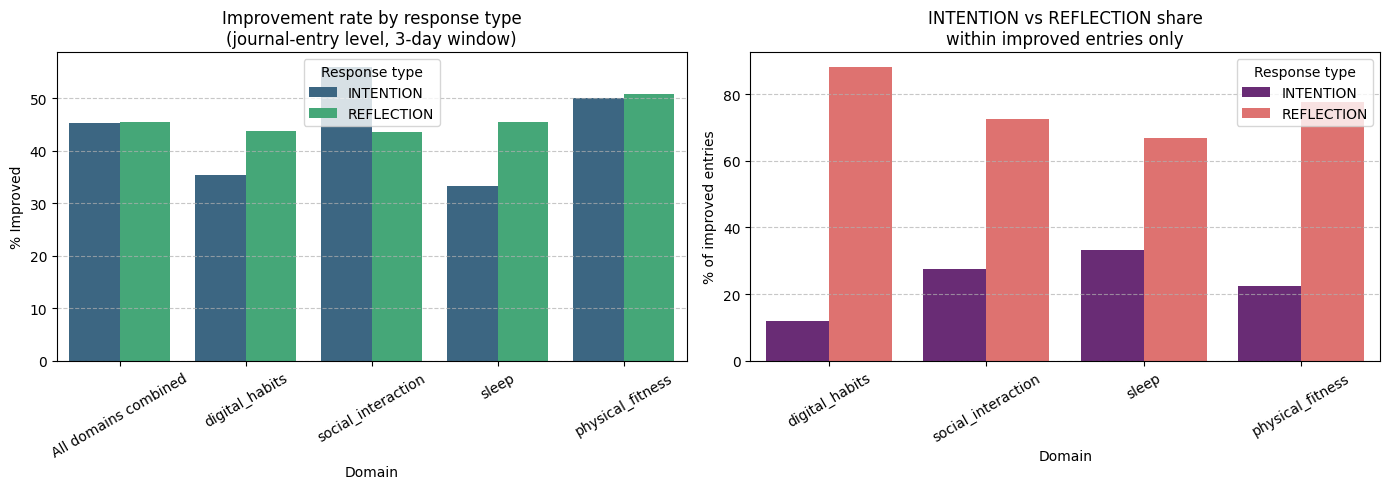

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Level 2 — improvement rate by domain ──────────────────────────────
plot_df = pd.DataFrame([overall] + domain_results)
plot_pct = plot_df[["label","intention_pct","reflection_pct"]].melt(
    id_vars="label", var_name="Group", value_name="% Improved"
)
plot_pct["Group"] = plot_pct["Group"].map(
    {"intention_pct":"INTENTION","reflection_pct":"REFLECTION"}
)
sns.barplot(ax=axes[0], x="label", y="% Improved",
            hue="Group", data=plot_pct, palette="viridis")
axes[0].set_title("Improvement rate by response type\n(journal-entry level, 3-day window)")
axes[0].set_xlabel("Domain"); axes[0].set_ylabel("% Improved")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Response type")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# ── Plot 2: Level 3 — INTENTION vs REFLECTION share within improved ───────────
imp_df = pd.DataFrame(improved_results)
plot_share = imp_df[["domain","pct_intention","pct_reflection"]].melt(
    id_vars="domain", var_name="Group", value_name="% of improved entries"
)
plot_share["Group"] = plot_share["Group"].map(
    {"pct_intention":"INTENTION","pct_reflection":"REFLECTION"}
)
sns.barplot(ax=axes[1], x="domain", y="% of improved entries",
            hue="Group", data=plot_share, palette="magma")
axes[1].set_title("INTENTION vs REFLECTION share\nwithin improved entries only")
axes[1].set_xlabel("Domain"); axes[1].set_ylabel("% of improved entries")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Response type")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# # ── Plot 3: Level 3 — median signal change within improved ───────────────────
# fig2, ax = plt.subplots(figsize=(10, 5))
# plot_delta = imp_df[["domain","intention_median_change","reflection_median_change"]].melt(
#     id_vars="domain", var_name="Group", value_name="Median signal Δ (z-score)"
# )
# plot_delta["Group"] = plot_delta["Group"].map(
#     {"intention_median_change":"INTENTION","reflection_median_change":"REFLECTION"}
# )
# sns.barplot(ax=ax, x="domain", y="Median signal Δ (z-score)",
#             hue="Group", data=plot_delta, palette="coolwarm")
# ax.set_title("Median signal change within improved entries\n(z-score units, 3-day window)")
# ax.set_xlabel("Domain"); ax.tick_params(axis="x", rotation=30)
# ax.legend(title="Response type")
# ax.grid(axis="y", linestyle="--", alpha=0.7)
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# plt.tight_layout()
# plt.show()


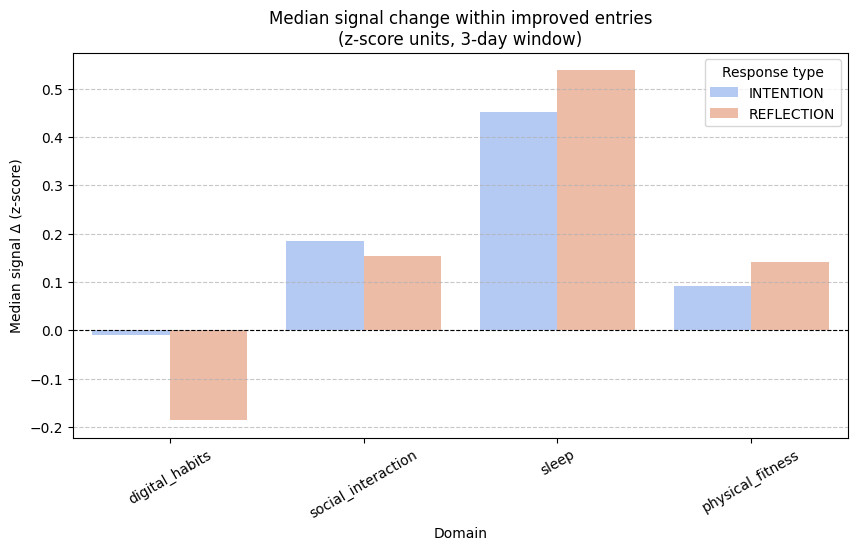

In [4]:
# ── Plot 3: Level 3 — median signal change within improved ───────────────────
fig2, ax = plt.subplots(figsize=(10, 5))
plot_delta = imp_df[["domain","intention_median_change","reflection_median_change"]].melt(
    id_vars="domain", var_name="Group", value_name="Median signal Δ (z-score)"
)
plot_delta["Group"] = plot_delta["Group"].map(
    {"intention_median_change":"INTENTION","reflection_median_change":"REFLECTION"}
)
sns.barplot(ax=ax, x="domain", y="Median signal Δ (z-score)",
            hue="Group", data=plot_delta, palette="coolwarm")
ax.set_title("Median signal change within improved entries\n(z-score units, 3-day window)")
ax.set_xlabel("Domain"); ax.tick_params(axis="x", rotation=30)
ax.legend(title="Response type")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# plt.tight_layout()
plt.show()